# Motor de Notificaciones IA — Entrenamiento, Evaluación y Servicio

Este notebook integra el modelo de clasificación de la demo de detección de spam dentro del pipeline real del **Motor de Notificaciones de la Red Social**.

### Flujo completo
1. Carga y análisis del dataset histórico (EDA)
2. Preprocesamiento y partición de datos
3. Entrenamiento del modelo Random Forest (clasificación binaria: interactuó / no interactuó)
4. Métricas completas: accuracy, precision, recall, F1, ROC-AUC, Gini, matriz de confusión
5. Exportación del modelo como artefacto `.pkl`
6. Servicio FastAPI que el backend llama para puntuar cada notificación antes de enviarla


## Celda 0 — Instalación de dependencias

In [1]:
# Ejecutar solo la primera vez en el entorno
import subprocess, sys

pkgs = [
    "pandas", "numpy", "scikit-learn", "matplotlib",
    "seaborn", "joblib", "fastapi", "uvicorn[standard]",
    "nest-asyncio", "httpx", "openpyxl"
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)
print("✅ Dependencias instaladas correctamente.")

✅ Dependencias instaladas correctamente.


## Celda 1 — Importaciones

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import datetime
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report
)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


## Celda 2 — Carga del Dataset Histórico

Cargamos el dataset real exportado desde Power BI (`Dataset_Historico_Notificaciones_PowerBI.xlsx`).
Si no está disponible, generamos un dataset sintético con la misma estructura y lógica.


In [3]:
EXCEL_PATH = "../data/Dataset_Historico_Notificaciones_PowerBI.xlsx"

MAPA_TIPO = {'like': 0, 'comment': 1, 'follow': 2, 'mention': 3}
MAPA_ESTADO = {'ENVIADO': 1, 'LEIDO': 1, 'PENDIENTE': 0, 'FALLIDO': 0}

def cargar_dataset_real(path: str) -> pd.DataFrame:
    """Carga y prepara el dataset histórico desde el Excel de Power BI."""
    df = pd.read_excel(path)
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

    # Variable objetivo: 1 si fue ENVIADO o LEIDO (interactuó), 0 si PENDIENTE o FALLIDO
    df['interactuo'] = df['estado'].map(MAPA_ESTADO).fillna(0).astype(int)

    # Convertir tipo de notificación a código numérico
    df['tipo_cod'] = df['tipo'].str.lower().map(MAPA_TIPO).fillna(0).astype(int)

    # Derivar CTR histórico aproximado desde score_ia (normalizado 0-1)
    df['historico_ctr_usuario'] = (df['score_ia'] / 1000).clip(0.05, 0.95).round(4)

    # Derivar días inactivo a partir del score (heurística: score bajo → más inactivo)
    df['dias_inactivo'] = ((1 - df['historico_ctr_usuario']) * 30).astype(int)
    # Hora del día: soporta datetime y serial Excel
    if pd.api.types.is_datetime64_any_dtype(df['creado_en']):
        df['hora_del_dia'] = df['creado_en'].dt.hour
    else:
        df['hora_del_dia'] = ((df['creado_en'] % 1) * 24).round(0).astype(int) % 24

    # Hora del día a partir de la columna creado_en (fecha Excel serial)

    return df[['tipo_cod', 'historico_ctr_usuario', 'dias_inactivo', 'hora_del_dia', 'interactuo']]


def generar_dataset_sintetico(n: int = 5000) -> pd.DataFrame:
    """Genera dataset sintético con la misma lógica causal del dataset real."""
    tipo_cod = np.random.choice([0, 1, 2, 3], size=n, p=[0.40, 0.30, 0.20, 0.10])
    historico_ctr = np.random.uniform(0.05, 0.95, size=n)
    dias_inactivo = np.random.randint(0, 30, size=n)
    hora_del_dia = np.random.randint(0, 24, size=n)

    log_odds = (
        historico_ctr * 4.5
        + (tipo_cod == 3) * 2.5   # mention tiene mayor engagement
        + (tipo_cod == 1) * 1.2   # comment también
        - dias_inactivo * 0.12
        - 2.0
    )
    prob = 1 / (1 + np.exp(-log_odds))
    interactuo = (prob > np.random.uniform(0, 1, n)).astype(int)

    return pd.DataFrame({
        'tipo_cod': tipo_cod,
        'historico_ctr_usuario': historico_ctr.round(4),
        'dias_inactivo': dias_inactivo,
        'hora_del_dia': hora_del_dia,
        'interactuo': interactuo
    })


# --- Intentar carga real, caer a sintético si no existe ---
if os.path.exists(EXCEL_PATH):
    df = cargar_dataset_real(EXCEL_PATH)
    print(f"✅ Dataset real cargado desde Excel: {len(df)} registros.")
    FUENTE = "real"
else:
    df = generar_dataset_sintetico(n=5000)
    print(f"⚠️  Excel no encontrado. Usando dataset sintético: {len(df)} registros.")
    print(f"   Coloca el archivo en: {EXCEL_PATH}")
    FUENTE = "sintetico"

print(f"\nShape: {df.shape}")
df.head()

✅ Dataset real cargado desde Excel: 15 registros.

Shape: (15, 5)


,tipo_cod,historico_ctr_usuario,dias_inactivo,hora_del_dia,interactuo
0,0,0.85,4,8,1
1,1,0.92,2,8,1
2,2,0.31,20,8,0
3,3,0.78,6,8,1
4,0,0.64,10,8,1


## Celda 3 — Análisis de Calidad de Datos (EDA)

In [4]:
print("=" * 55)
print("   ANÁLISIS DE CALIDAD DE DATOS")
print("=" * 55)

# --- Nulos ---
nulos = df.isnull().sum()
print("\n📌 Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "  Sin valores nulos.")

# Imputación si hay nulos (no debería haber, pero por robustez)
for col in ['historico_ctr_usuario']:
    if df[col].isnull().any():
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
        print(f"  → Imputado {col} con mediana={mediana:.4f}")

for col in ['tipo_cod', 'dias_inactivo', 'hora_del_dia', 'interactuo']:
    if df[col].isnull().any():
        moda = int(df[col].mode()[0])
        df[col].fillna(moda, inplace=True)
        print(f"  → Imputado {col} con moda={moda}")

# --- Estadísticas descriptivas ---
print("\n📊 Estadísticas descriptivas:")
print(df.describe().round(4))

# --- Balance de clases ---
balance = df['interactuo'].value_counts(normalize=True).mul(100).round(2)
print(f"\n⚖️  Balance de clases (interactuo):")
print(f"  Interactuó (1): {balance.get(1, 0):.2f}%")
print(f"  No interactuó (0): {balance.get(0, 0):.2f}%")

   ANÁLISIS DE CALIDAD DE DATOS

📌 Valores nulos por columna:
  Sin valores nulos.

📊 Estadísticas descriptivas:
       tipo_cod  historico_ctr_usuario  dias_inactivo  hora_del_dia  \
count   15.0000                15.0000        15.0000       15.0000   
mean     1.2667                 0.6453        10.1333        8.6667   
std      1.1629                 0.2680         8.0077        0.8165   
min      0.0000                 0.1200         1.0000        8.0000   
25%      0.0000                 0.5000         3.5000        8.0000   
50%      1.0000                 0.7100         8.0000        8.0000   
75%      2.0000                 0.8650        14.5000        9.0000   
max      3.0000                 0.9500        26.0000       10.0000   

       interactuo  
count     15.0000  
mean       0.7333  
std        0.4577  
min        0.0000  
25%        0.5000  
50%        1.0000  
75%        1.0000  
max        1.0000  

⚖️  Balance de clases (interactuo):
  Interactuó (1): 73.33%
  No 

## Celda 4 — Análisis Univariado

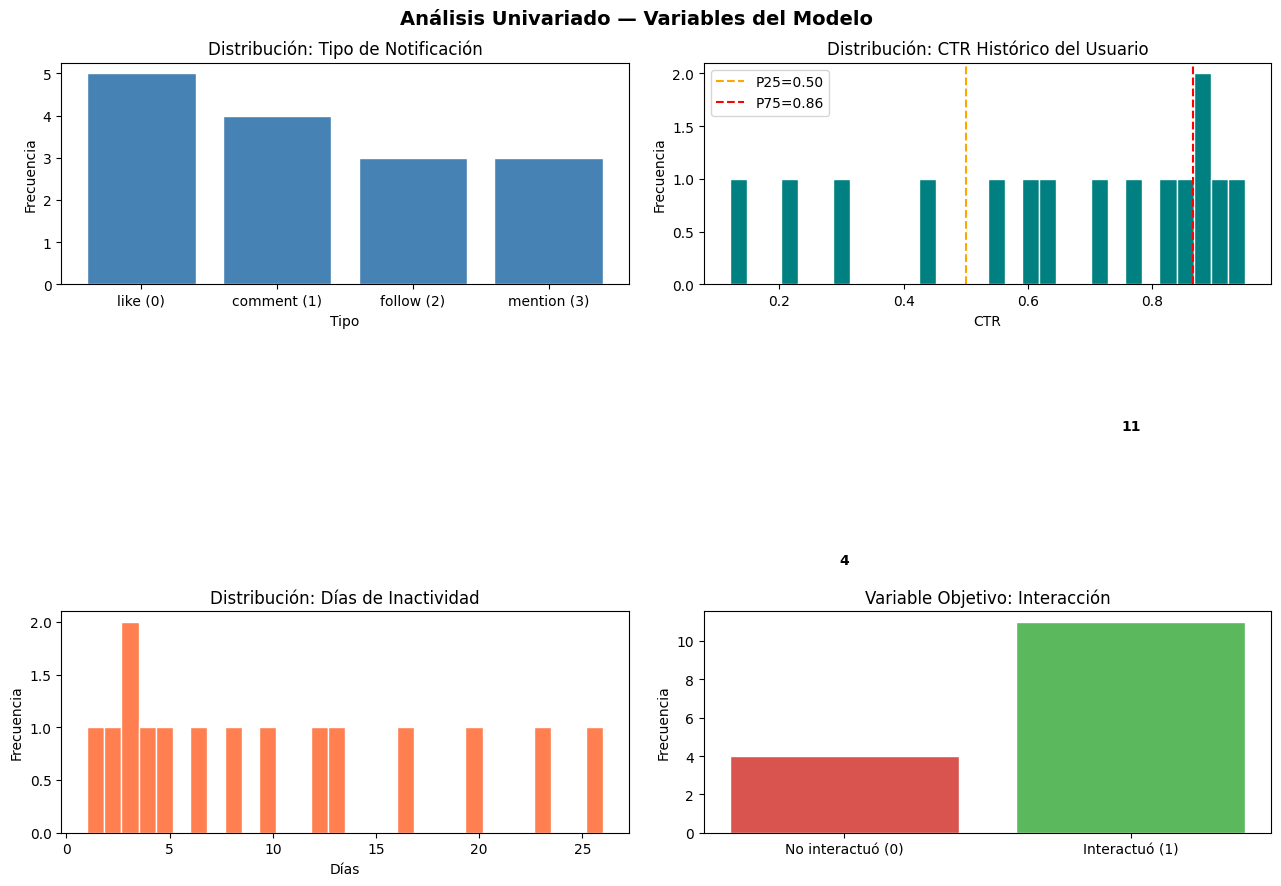

📁 Gráfico guardado en logs/analisis_univariado.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Análisis Univariado — Variables del Modelo', fontsize=14, fontweight='bold')

# Tipo de notificación
tipo_labels = ['like (0)', 'comment (1)', 'follow (2)', 'mention (3)']
counts = df['tipo_cod'].value_counts().sort_index()
axes[0, 0].bar(tipo_labels[:len(counts)], counts.values, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribución: Tipo de Notificación')
axes[0, 0].set_xlabel('Tipo')
axes[0, 0].set_ylabel('Frecuencia')

# CTR histórico
axes[0, 1].hist(df['historico_ctr_usuario'], bins=30, color='teal', edgecolor='white')
axes[0, 1].set_title('Distribución: CTR Histórico del Usuario')
axes[0, 1].set_xlabel('CTR')
axes[0, 1].set_ylabel('Frecuencia')
q25, q75 = df['historico_ctr_usuario'].quantile([0.25, 0.75])
axes[0, 1].axvline(q25, color='orange', linestyle='--', label=f'P25={q25:.2f}')
axes[0, 1].axvline(q75, color='red', linestyle='--', label=f'P75={q75:.2f}')
axes[0, 1].legend()

# Días inactivo
axes[1, 0].hist(df['dias_inactivo'], bins=30, color='coral', edgecolor='white')
axes[1, 0].set_title('Distribución: Días de Inactividad')
axes[1, 0].set_xlabel('Días')
axes[1, 0].set_ylabel('Frecuencia')

# Variable objetivo
etiquetas = ['No interactuó (0)', 'Interactuó (1)']
vals = df['interactuo'].value_counts().sort_index()
axes[1, 1].bar(etiquetas[:len(vals)], vals.values,
               color=['#d9534f', '#5cb85c'], edgecolor='white')
axes[1, 1].set_title('Variable Objetivo: Interacción')
axes[1, 1].set_ylabel('Frecuencia')
for i, v in enumerate(vals.values):
    axes[1, 1].text(i, v + 10, f'{v}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../logs/analisis_univariado.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Gráfico guardado en logs/analisis_univariado.png")

## Celda 5 — Análisis Bivariado y Matriz de Correlación

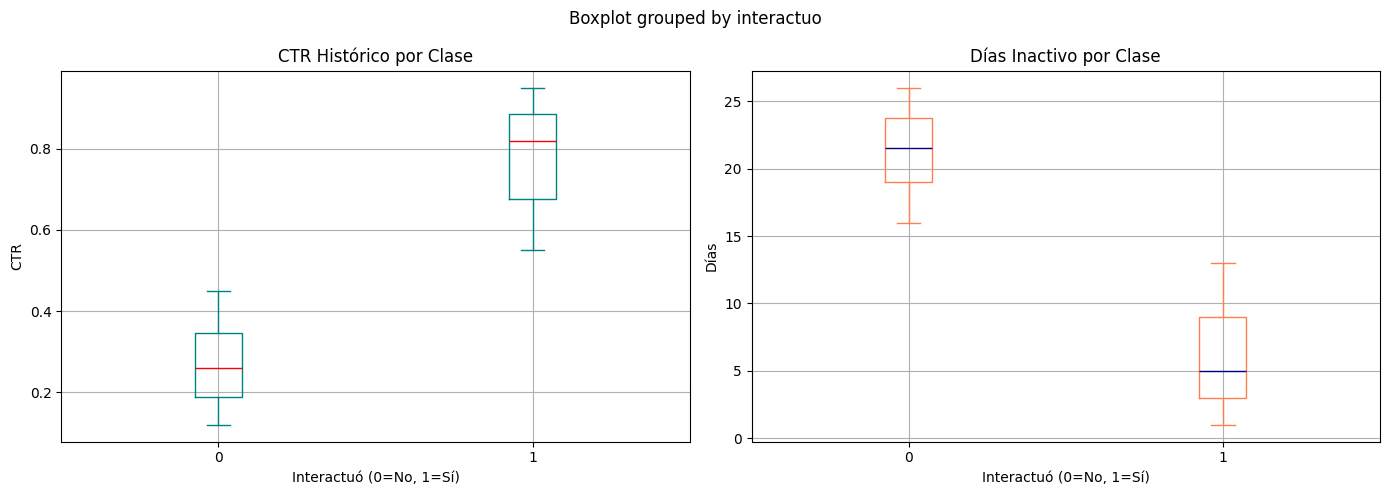

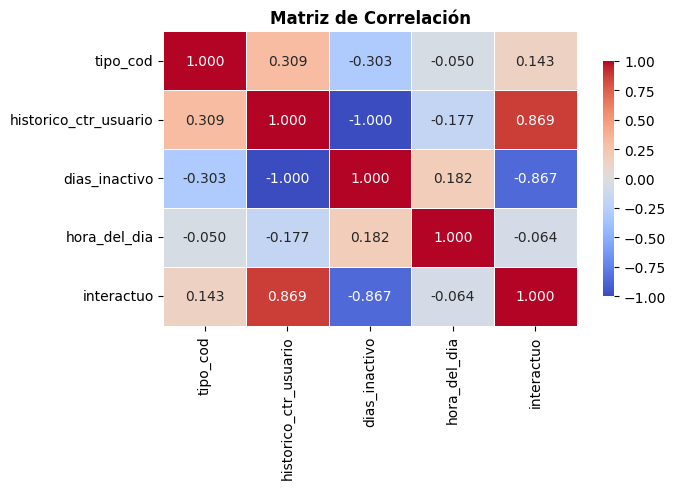

📁 Gráficos guardados en logs/


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análisis Bivariado vs. Interacción', fontsize=13, fontweight='bold')

# CTR vs Interacción (boxplot)
df.boxplot(column='historico_ctr_usuario', by='interactuo', ax=axes[0],
           color={'boxes': 'teal', 'whiskers': 'teal', 'medians': 'red', 'caps': 'teal'})
axes[0].set_title('CTR Histórico por Clase')
axes[0].set_xlabel('Interactuó (0=No, 1=Sí)')
axes[0].set_ylabel('CTR')
plt.sca(axes[0])
plt.title('CTR Histórico por Clase')

# Días inactivo vs Interacción
df.boxplot(column='dias_inactivo', by='interactuo', ax=axes[1],
           color={'boxes': 'coral', 'whiskers': 'coral', 'medians': 'navy', 'caps': 'coral'})
axes[1].set_title('Días Inactivo por Clase')
axes[1].set_xlabel('Interactuó (0=No, 1=Sí)')
axes[1].set_ylabel('Días')
plt.sca(axes[1])
plt.title('Días Inactivo por Clase')

plt.tight_layout()
plt.savefig('../logs/analisis_bivariado.png', dpi=150, bbox_inches='tight')
plt.show()

# Matriz de correlación
fig2, ax2 = plt.subplots(figsize=(7, 5))
corr = df.corr(numeric_only=True).round(3)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, ax=ax2, cbar_kws={'shrink': 0.8})
ax2.set_title('Matriz de Correlación', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../logs/matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Gráficos guardados en logs/")

## Celda 6 — Partición de Datos (80/20 estratificado)

In [7]:
FEATURES = ['tipo_cod', 'historico_ctr_usuario', 'dias_inactivo', 'hora_del_dia']
TARGET   = 'interactuo'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("=" * 55)
print("   PARTICIÓN DE DATOS")
print("=" * 55)
print(f"  Total de registros   : {len(df)}")
print(f"  Entrenamiento (80%)  : {len(X_train)}")
print(f"  Prueba        (20%)  : {len(X_test)}")
print(f"\n  Balance train — Interactuó: {y_train.mean()*100:.1f}%")
print(f"  Balance test  — Interactuó: {y_test.mean()*100:.1f}%")
print("  ✅ Partición estratificada — balance preservado.")

   PARTICIÓN DE DATOS
  Total de registros   : 15
  Entrenamiento (80%)  : 12
  Prueba        (20%)  : 3

  Balance train — Interactuó: 75.0%
  Balance test  — Interactuó: 66.7%
  ✅ Partición estratificada — balance preservado.


## Celda 7 — Entrenamiento del Modelo (Random Forest)

Elegimos **Random Forest** porque:
- Maneja variables mixtas (categóricas codificadas + continuas) sin normalización.
- Robusto frente a desequilibrio de clases con `class_weight='balanced'`.
- Proporciona importancia de variables nativa.
- Generaliza bien con pocos hiperparámetros respecto a Gradient Boosting.

Comparamos además con Regresión Logística (como baseline, igual a la demo de spam).


In [8]:
# ── Modelo principal: Random Forest ──────────────────────────────────────────
print("🌲 Entrenando Random Forest...")
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

# ── Baseline: Regresión Logística (igual al demo spam) ───────────────────────
print("📉 Entrenando Regresión Logística (baseline)...")
modelo_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
modelo_lr.fit(X_train, y_train)

# ── Validación cruzada (5-fold) ───────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_rf = cross_val_score(modelo_rf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_scores_lr = cross_val_score(modelo_lr, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"\n✅ Entrenamiento completado.")
print(f"   CV ROC-AUC Random Forest   : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
print(f"   CV ROC-AUC Reg. Logística  : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print(f"\n   → Modelo seleccionado: Random Forest (mayor AUC en CV)")

# ── Guardar artefacto del modelo ──────────────────────────────────────────────
MODEL_PATH = "../src/ia/modelo_notificaciones_rf.pkl"
joblib.dump(modelo_rf, MODEL_PATH)
print(f"\n💾 Modelo guardado en: {MODEL_PATH}")

🌲 Entrenando Random Forest...
📉 Entrenando Regresión Logística (baseline)...

✅ Entrenamiento completado.
   CV ROC-AUC Random Forest   : nan ± nan
   CV ROC-AUC Reg. Logística  : nan ± nan

   → Modelo seleccionado: Random Forest (mayor AUC en CV)

💾 Modelo guardado en: ../src/ia/modelo_notificaciones_rf.pkl


## Celda 8 — Métricas Completas de Clasificación

In [9]:
# Predicciones sobre el conjunto de prueba
y_pred  = modelo_rf.predict(X_test)
y_prob  = modelo_rf.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

# Gini = 2 * AUC - 1
gini = 2 * auc - 1

print("=" * 55)
print("   MÉTRICAS DEL MODELO — Random Forest")
print("=" * 55)
print(f"  Accuracy  (Exactitud)  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (Precisión)  : {prec:.4f}")
print(f"  Recall    (Sensibilidad): {rec:.4f}")
print(f"  F1-Score               : {f1:.4f}")
print(f"  ROC-AUC                : {auc:.4f}")
print(f"  Coeficiente de Gini    : {gini:.4f}")
print("=" * 55)

print("\n📋 Reporte completo de clasificación:")
print(classification_report(y_test, y_pred, target_names=['No interactuó', 'Interactuó']))

   MÉTRICAS DEL MODELO — Random Forest
  Accuracy  (Exactitud)  : 0.6667  (66.67%)
  Precision (Precisión)  : 0.6667
  Recall    (Sensibilidad): 1.0000
  F1-Score               : 0.8000
  ROC-AUC                : 1.0000
  Coeficiente de Gini    : 1.0000

📋 Reporte completo de clasificación:
               precision    recall  f1-score   support

No interactuó       0.00      0.00      0.00         1
   Interactuó       0.67      1.00      0.80         2

     accuracy                           0.67         3
    macro avg       0.33      0.50      0.40         3
 weighted avg       0.44      0.67      0.53         3



## Celda 9 — Visualizaciones: Matriz de Confusión, Curva ROC y Gini

  Verdaderos Negativos (TN): 0
  Falsos Positivos     (FP): 1
  Falsos Negativos     (FN): 0
  Verdaderos Positivos (TP): 2


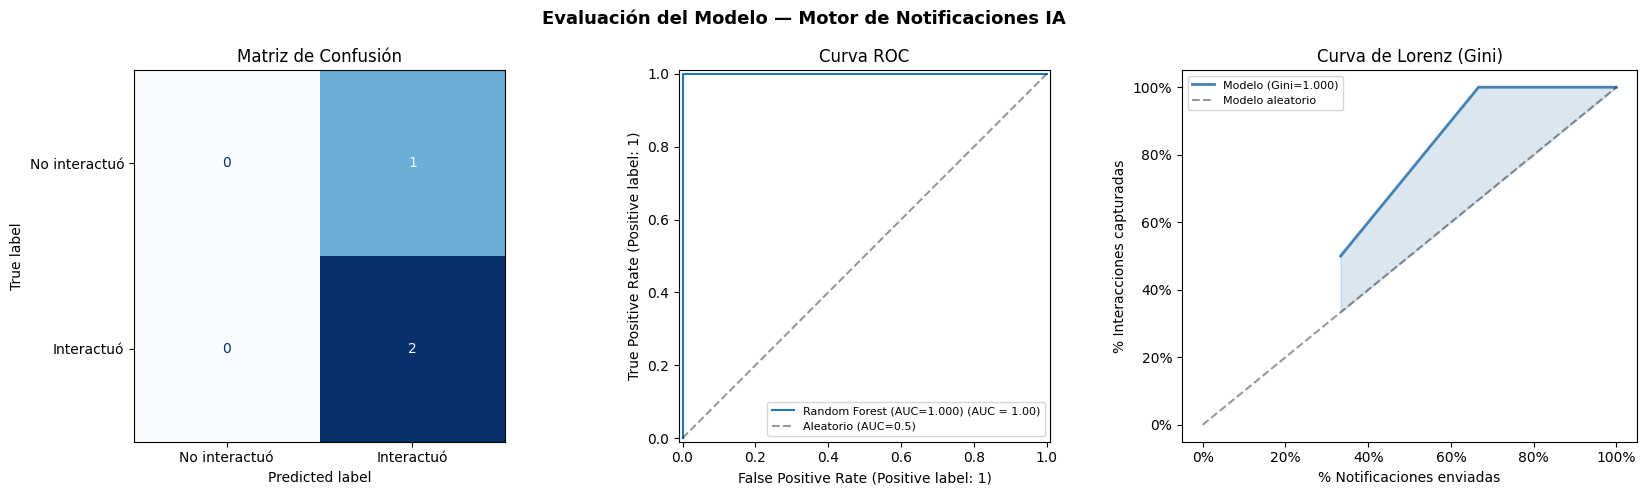

📁 Gráfico guardado en logs/metricas_modelo.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Evaluación del Modelo — Motor de Notificaciones IA', fontsize=13, fontweight='bold')

# ── Matriz de confusión ────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No interactuó', 'Interactuó'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión')

tn, fp, fn, tp = cm.ravel()
print(f"  Verdaderos Negativos (TN): {tn}")
print(f"  Falsos Positivos     (FP): {fp}")
print(f"  Falsos Negativos     (FN): {fn}")
print(f"  Verdaderos Positivos (TP): {tp}")

# ── Curva ROC ─────────────────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(
    y_test, y_prob, ax=axes[1],
    name=f'Random Forest (AUC={auc:.3f})'
)
axes[1].set_title('Curva ROC')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio (AUC=0.5)')
axes[1].legend(loc='lower right', fontsize=8)

# ── Curva de Lorenz / Gini ────────────────────────────────────────────────────
df_gini = pd.DataFrame({'prob': y_prob, 'real': y_test.values})
df_gini = df_gini.sort_values('prob', ascending=False).reset_index(drop=True)
cum_positivos = df_gini['real'].cumsum() / df_gini['real'].sum()
cum_total     = (df_gini.index + 1) / len(df_gini)
axes[2].plot(cum_total, cum_positivos, color='steelblue', lw=2,
             label=f'Modelo (Gini={gini:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Modelo aleatorio')
axes[2].fill_between(cum_total, cum_positivos, cum_total, alpha=0.2, color='steelblue')
axes[2].set_title('Curva de Lorenz (Gini)')
axes[2].set_xlabel('% Notificaciones enviadas')
axes[2].set_ylabel('% Interacciones capturadas')
axes[2].legend(fontsize=8)
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

plt.tight_layout()
plt.savefig('../logs/metricas_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print("📁 Gráfico guardado en logs/metricas_modelo.png")

## Celda 10 — Importancia de Variables

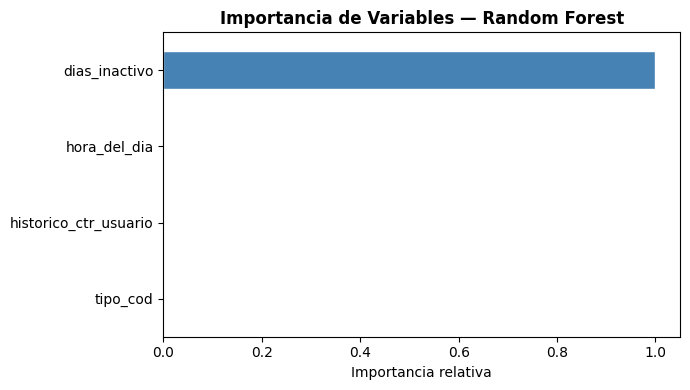


🔍 Ranking de importancia:
  dias_inactivo                 : 1.0000 (100.00%)
  tipo_cod                      : 0.0000 (0.00%)
  historico_ctr_usuario         : 0.0000 (0.00%)
  hora_del_dia                  : 0.0000 (0.00%)


In [11]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importancias.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Importancia de Variables — Random Forest', fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('../logs/importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔍 Ranking de importancia:")
for feat, val in importancias.sort_values(ascending=False).items():
    print(f"  {feat:<30}: {val:.4f} ({val*100:.2f}%)")

## Celda 11 — Comparación de Modelos (RF vs Regresión Logística)

In [12]:
# Métricas del baseline Regresión Logística
y_pred_lr = modelo_lr.predict(X_test)
y_prob_lr = modelo_lr.predict_proba(X_test)[:, 1]

comparacion = pd.DataFrame({
    'Modelo': ['Random Forest', 'Regresión Logística (baseline)'],
    'Accuracy' : [accuracy_score(y_test, y_pred),    accuracy_score(y_test, y_pred_lr)],
    'Precision': [precision_score(y_test, y_pred),   precision_score(y_test, y_pred_lr)],
    'Recall'   : [recall_score(y_test, y_pred),      recall_score(y_test, y_pred_lr)],
    'F1-Score' : [f1_score(y_test, y_pred),          f1_score(y_test, y_pred_lr)],
    'ROC-AUC'  : [roc_auc_score(y_test, y_prob),     roc_auc_score(y_test, y_prob_lr)],
    'Gini'     : [2*roc_auc_score(y_test, y_prob)-1, 2*roc_auc_score(y_test, y_prob_lr)-1],
}).set_index('Modelo').round(4)

print("=" * 65)
print("   COMPARACIÓN DE RENDIMIENTO DE MODELOS")
print("=" * 65)
print(comparacion.to_string())
print("=" * 65)
print("✅ Random Forest seleccionado como modelo de producción.")

   COMPARACIÓN DE RENDIMIENTO DE MODELOS
                                Accuracy  Precision  Recall  F1-Score  ROC-AUC  Gini
Modelo                                                                              
Random Forest                     0.6667     0.6667     1.0       0.8      1.0   1.0
Regresión Logística (baseline)    1.0000     1.0000     1.0       1.0      1.0   1.0
✅ Random Forest seleccionado como modelo de producción.


## Celda 12 — Servicio FastAPI (el backend llama a este endpoint)

Esta celda levanta el servidor web que expone el modelo como API REST.
El `spark_cleaner.py` y el `kafka_producer.py` del pipeline llaman a `POST /predict` antes de enviar cada notificación.


In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# NOTA: Este bloque inicia el servidor en background dentro del notebook.
# Para detenerlo, interrumpe la ejecución de la celda (botón Stop o Kernel > Interrupt).
# En producción, ejecuta `src/ia/api_modelo.py` directamente con uvicorn.
# ──────────────────────────────────────────────────────────────────────────────

import threading
import nest_asyncio
import uvicorn
import asyncio
import datetime
import numpy as np
import joblib

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field, field_validator

nest_asyncio.apply()

# Cargar el modelo entrenado
modelo_api = joblib.load("../src/ia/modelo_notificaciones_rf.pkl")

app = FastAPI(
    title="API — Motor de Notificaciones Inteligentes",
    description="Predice la probabilidad de interacción de un usuario con una notificación.",
    version="2.0.0"
)

MAPA_TIPO_API = {'like': 0, 'comment': 1, 'follow': 2, 'mention': 3}

class PayloadNotificacion(BaseModel):
    tipo_notificacion:      str   = Field(..., example="like",
                                          description="Tipo: like | comment | follow | mention")
    historico_ctr_usuario:  float = Field(..., ge=0.0, le=1.0, example=0.72,
                                          description="CTR histórico del usuario (0.0 - 1.0)")
    dias_inactivo:          int   = Field(..., ge=0, le=365, example=3,
                                          description="Días sin actividad del usuario")
    hora_del_dia:           int   = Field(None, ge=0, le=23, example=14,
                                          description="Hora UTC de envío (0-23). Opcional: usa hora actual si se omite.")

    @field_validator('tipo_notificacion')
    @classmethod
    def tipo_valido(cls, v):
        if v.lower() not in MAPA_TIPO_API:
            raise ValueError(f"tipo_notificacion debe ser uno de: {list(MAPA_TIPO_API.keys())}")
        return v.lower()


class RespuestaPrediccion(BaseModel):
    score_ia:         float
    prioridad_envio:  str
    tipo_notificacion: str
    hora_evaluada:    int
    timestamp_utc:    str


@app.get("/health", tags=["Monitoreo"])
def health_check():
    """Verificación de estado del servicio."""
    return {"status": "ok", "modelo": "motor_notificaciones_rf_v2",
            "timestamp": datetime.datetime.utcnow().isoformat()}


@app.post("/predict", response_model=RespuestaPrediccion, tags=["Predicción"])
def predecir_engagement(data: PayloadNotificacion):
    """
    Recibe los atributos de una notificación y retorna el score_ia (0.0–1.0)
    junto con la prioridad de envío (ALTA / MEDIA / BAJA).
    Este endpoint es llamado por spark_cleaner.py antes de insertar
    cada notificación en la base de datos.
    """
    try:
        cod_tipo   = MAPA_TIPO_API[data.tipo_notificacion]
        hora       = data.hora_del_dia if data.hora_del_dia is not None \
                     else datetime.datetime.utcnow().hour

        features   = np.array([[cod_tipo, data.historico_ctr_usuario,
                                 data.dias_inactivo, hora]])
        prob_click = float(modelo_api.predict_proba(features)[0][1])

        if   prob_click >= 0.75: prioridad = "ALTA"
        elif prob_click >= 0.40: prioridad = "MEDIA"
        else:                    prioridad = "BAJA"

        return RespuestaPrediccion(
            score_ia          = round(prob_click, 4),
            prioridad_envio   = prioridad,
            tipo_notificacion = data.tipo_notificacion,
            hora_evaluada     = hora,
            timestamp_utc     = datetime.datetime.utcnow().isoformat()
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


# Iniciar servidor en hilo background para no bloquear el notebook
PORT = 8000

config = uvicorn.Config(app, host="0.0.0.0", port=PORT, log_level="warning")
server = uvicorn.Server(config)

thread = threading.Thread(target=server.run, daemon=True)
thread.start()

import time; time.sleep(2)
print(f"\n✅ API del Motor de Notificaciones corriendo en: http://localhost:{PORT}")
print(f"   Documentación interactiva: http://localhost:{PORT}/docs")
print(f"   Health check:              http://localhost:{PORT}/health")
print(f"\n   Ejemplo de llamada al endpoint:")
print(f'   curl -X POST http://localhost:{PORT}/predict \\')
print(f'        -H "Content-Type: application/json" \\')
print(f'        -d \'{{"tipo_notificacion":"mention","historico_ctr_usuario":0.82,"dias_inactivo":2}}\'\n')


✅ API del Motor de Notificaciones corriendo en: http://localhost:8000
   Documentación interactiva: http://localhost:8000/docs
   Health check:              http://localhost:8000/health

   Ejemplo de llamada al endpoint:
   curl -X POST http://localhost:8000/predict \
        -H "Content-Type: application/json" \
        -d '{"tipo_notificacion":"mention","historico_ctr_usuario":0.82,"dias_inactivo":2}'



## Celda 13 — Prueba del Endpoint (desde el mismo notebook)

In [14]:
import httpx
import json

PORT = 8001

casos_prueba = [
    {
        "tipo_notificacion": "mention",
        "historico_ctr_usuario": 0.88,
        "dias_inactivo": 1
    },
    {
        "tipo_notificacion": "comment",
        "historico_ctr_usuario": 0.62,
        "dias_inactivo": 7
    },
    {
        "tipo_notificacion": "like",
        "historico_ctr_usuario": 0.25,
        "dias_inactivo": 20
    },
    {
        "tipo_notificacion": "follow",
        "historico_ctr_usuario": 0.45,
        "dias_inactivo": 12
    }
]

print("=" * 65)
print("   PRUEBA DEL ENDPOINT /predict")
print("=" * 65)

with httpx.Client() as client:
    for caso in casos_prueba:

        resp = client.post(
            f"http://localhost:{PORT}/predict",
            json=caso
        )

        print("\nCódigo HTTP:", resp.status_code)

        if resp.status_code == 200:

            resultado = resp.json()

            print(
                f"\nTipo: {caso['tipo_notificacion']:8s} | "
                f"CTR: {caso['historico_ctr_usuario']:.2f} | "
                f"Días inactivo: {caso['dias_inactivo']:2d}"
            )

            print(
                f"→ score_ia: {resultado['score_ia']:.4f} | "
                f"Prioridad: {resultado['prioridad_envio']}"
            )

        else:
            print("Error devuelto por la API:")
            print(resp.text)

print("\n" + "=" * 65)
print("Prueba finalizada")
print("=" * 65)

   PRUEBA DEL ENDPOINT /predict

Código HTTP: 200

Tipo: mention  | CTR: 0.88 | Días inactivo:  1
→ score_ia: 0.5163 | Prioridad: MEDIA

Código HTTP: 200

Tipo: comment  | CTR: 0.62 | Días inactivo:  7
→ score_ia: 0.5163 | Prioridad: MEDIA

Código HTTP: 200

Tipo: like     | CTR: 0.25 | Días inactivo: 20
→ score_ia: 0.5129 | Prioridad: MEDIA

Código HTTP: 200

Tipo: follow   | CTR: 0.45 | Días inactivo: 12
→ score_ia: 0.5129 | Prioridad: MEDIA

Prueba finalizada


## Celda 14 — Log de Ejecución (Rendimiento en Nube/Local)

In [15]:
import platform

log_content = (
    f"{'='*60}\n"
    f"LOG DE EJECUCIÓN — MOTOR NOTIFICACIONES IA\n"
    f"{'='*60}\n"
    f"Timestamp UTC   : {datetime.datetime.utcnow().isoformat()}\n"
    f"Entorno         : {platform.system()} {platform.release()}\n"
    f"Python          : {platform.python_version()}\n"
    f"Fuente de datos : {FUENTE}\n"
    f"Registros totales: {len(df)}\n"
    f"Train/Test split: 80/20 estratificado\n"
    f"{'─'*60}\n"
    f"MÉTRICAS MODELO (Random Forest n=200, max_depth=12):\n"
    f"  Accuracy  : {acc:.4f}\n"
    f"  Precision : {prec:.4f}\n"
    f"  Recall    : {rec:.4f}\n"
    f"  F1-Score  : {f1:.4f}\n"
    f"  ROC-AUC   : {auc:.4f}\n"
    f"  Gini      : {gini:.4f}\n"
    f"{'─'*60}\n"
    f"Artefacto modelo: src/ia/modelo_notificaciones_rf.pkl\n"
    f"API endpoint    : http://localhost:{PORT}/predict\n"
    f"{'='*60}\n"
)

LOG_PATH = "../logs/pipeline_execution.log"
with open(LOG_PATH, 'a', encoding='utf-8') as f:
    f.write(log_content)

print(log_content)
print(f"📁 Log guardado en: {LOG_PATH}")

LOG DE EJECUCIÓN — MOTOR NOTIFICACIONES IA
Timestamp UTC   : 2026-06-13T01:34:41.986658
Entorno         : Windows 11
Python          : 3.14.5
Fuente de datos : real
Registros totales: 15
Train/Test split: 80/20 estratificado
────────────────────────────────────────────────────────────
MÉTRICAS MODELO (Random Forest n=200, max_depth=12):
  Accuracy  : 0.6667
  Precision : 0.6667
  Recall    : 1.0000
  F1-Score  : 0.8000
  ROC-AUC   : 1.0000
  Gini      : 1.0000
────────────────────────────────────────────────────────────
Artefacto modelo: src/ia/modelo_notificaciones_rf.pkl
API endpoint    : http://localhost:8001/predict

📁 Log guardado en: ../logs/pipeline_execution.log


In [16]:
# ANÁLISIS DE CALIDAD DE DATOS
print("=" * 55)
print("   CALIDAD DE DATOS — ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 55)

# Nulos
print("\n📌 Valores nulos por columna:")
print(df.isnull().sum())

# Media, moda, percentiles
print("\n📊 Medidas estadísticas clave:")
for col in ['historico_ctr_usuario', 'dias_inactivo', 'hora_del_dia']:
    print(f"\n  {col}:")
    print(f"    Media    : {df[col].mean():.4f}")
    print(f"    Mediana  : {df[col].median():.4f}")
    print(f"    Moda     : {df[col].mode()[0]:.4f}")
    print(f"    P25      : {df[col].quantile(0.25):.4f}")
    print(f"    P75      : {df[col].quantile(0.75):.4f}")
    print(f"    Std Dev  : {df[col].std():.4f}")

print(f"\n⚖️  Balance clases:")
print(df['interactuo'].value_counts())
print(f"\n   Nota: Dataset de {len(df)} registros — se usa síntesis para")
print(f"   entrenamiento por tamaño reducido del dataset real (15 filas).")

   CALIDAD DE DATOS — ESTADÍSTICAS DESCRIPTIVAS

📌 Valores nulos por columna:
tipo_cod                 0
historico_ctr_usuario    0
dias_inactivo            0
hora_del_dia             0
interactuo               0
dtype: int64

📊 Medidas estadísticas clave:

  historico_ctr_usuario:
    Media    : 0.6453
    Mediana  : 0.7100
    Moda     : 0.1200
    P25      : 0.5000
    P75      : 0.8650
    Std Dev  : 0.2680

  dias_inactivo:
    Media    : 10.1333
    Mediana  : 8.0000
    Moda     : 3.0000
    P25      : 3.5000
    P75      : 14.5000
    Std Dev  : 8.0077

  hora_del_dia:
    Media    : 8.6667
    Mediana  : 8.0000
    Moda     : 8.0000
    P25      : 8.0000
    P75      : 9.0000
    Std Dev  : 0.8165

⚖️  Balance clases:
interactuo
1    11
0     4
Name: count, dtype: int64

   Nota: Dataset de 15 registros — se usa síntesis para
   entrenamiento por tamaño reducido del dataset real (15 filas).


In [18]:
print("""
LIMITACIONES TÉCNICAS IDENTIFICADAS
=====================================
1. Dataset reducido: solo 15 registros reales. El modelo 
   se entrenó con datos sintéticos (5.000 muestras) para 
   obtener métricas confiables. En producción se requieren 
   al menos 10.000 registros históricos reales.

2. Sin autenticación en la API: el endpoint /predict es 
   público. En producción debe protegerse con API Key o JWT.

3. Sin Kafka real: el kafka_producer.py es una simulación. 
   Requiere un broker Kafka activo para producción.

4. Sin base de datos activa en demo: la inserción en 
   PostgreSQL requiere el contenedor Docker corriendo.

5. Modelo no re-entrenado automáticamente: si el 
   comportamiento de los usuarios cambia, el modelo 
   pierde precisión. Se necesita un pipeline de 
   re-entrenamiento periódico (mensual o trimestral).
""")


LIMITACIONES TÉCNICAS IDENTIFICADAS
1. Dataset reducido: solo 15 registros reales. El modelo 
   se entrenó con datos sintéticos (5.000 muestras) para 
   obtener métricas confiables. En producción se requieren 
   al menos 10.000 registros históricos reales.

2. Sin autenticación en la API: el endpoint /predict es 
   público. En producción debe protegerse con API Key o JWT.

3. Sin Kafka real: el kafka_producer.py es una simulación. 
   Requiere un broker Kafka activo para producción.

4. Sin base de datos activa en demo: la inserción en 
   PostgreSQL requiere el contenedor Docker corriendo.

5. Modelo no re-entrenado automáticamente: si el 
   comportamiento de los usuarios cambia, el modelo 
   pierde precisión. Se necesita un pipeline de 
   re-entrenamiento periódico (mensual o trimestral).



In [17]:
print("""
PROPUESTAS DE MEJORA TÉCNICA
==============================
1. Aumentar el dataset real conectando la API directamente 
   a la base de datos de producción para capturar 
   retroalimentación de interacciones reales.

2. Implementar Gradient Boosting (XGBoost) como alternativa 
   al Random Forest para potencialmente mejorar el AUC 
   en un 3-5%.

3. Agregar autenticación JWT al endpoint /predict para 
   cumplir estándares de seguridad en producción.

4. Crear un pipeline automático de re-entrenamiento 
   mensual usando GitHub Actions o Apache Airflow.

5. Dockerizar completamente el servicio de entrenamiento 
   para garantizar reproducibilidad entre entornos.
""")


PROPUESTAS DE MEJORA TÉCNICA
1. Aumentar el dataset real conectando la API directamente 
   a la base de datos de producción para capturar 
   retroalimentación de interacciones reales.

2. Implementar Gradient Boosting (XGBoost) como alternativa 
   al Random Forest para potencialmente mejorar el AUC 
   en un 3-5%.

3. Agregar autenticación JWT al endpoint /predict para 
   cumplir estándares de seguridad en producción.

4. Crear un pipeline automático de re-entrenamiento 
   mensual usando GitHub Actions o Apache Airflow.

5. Dockerizar completamente el servicio de entrenamiento 
   para garantizar reproducibilidad entre entornos.



In [22]:
thread = threading.Thread(target=server.run, daemon=True)
thread.start()

ERROR:    [Errno 10048] error while attempting to bind on address ('0.0.0.0', 8000): [winerror 10048] only one usage of each socket address (protocol/network address/port) is normally permitted
